---
# DNN : `spam` (avec `Keras`, ajout d'un "callback" et d'un "dropout")
---

## Packages

In [23]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from keras import callbacks, layers, models

---
## 1. Données
---

### 1.1. Importation

In [24]:
# En local :
directory = 'data/'

# Sur Google collab ou Onyxia (sur un répertoire temporaire) :
# directory = ''

# Sur Google collab (sur le drive) :
# from google.colab import drive
# drive.mount('/content/drive')
# directory = '/content/drive/MyDrive/Data/'

In [25]:
data = pd.read_csv(directory + 'spam.csv',
                   header    = 0,
                   # index_col = 0,
                   sep       = ',',
                   decimal   = '.')

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [27]:
data.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_leftbrac,char_freq_leftsquarebrac,char_freq_exclaim,char_freq_dollar,char_freq_pound,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


### 1.2. Gestion des données manquantes

In [28]:
missing_percentage = data.isna().mean() * 100

print('MISSING VALUES :')
if missing_percentage[missing_percentage != 0].empty:
    print('No')
else:
    print(missing_percentage[missing_percentage != 0].sort_values(ascending=False))

MISSING VALUES :
No


### 1.3. Gestion des variables

In [29]:
target = 'spam'

y = data[target]
X = data.drop(target, axis=1)

### 1.4. Création des échantillons de validation et test

In [30]:
test_portion  = 1/5
valid_portion = 1/5

X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size=test_portion)

X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=valid_portion)

print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_valid :', X_valid.shape)
print('Dimensions de X_test  :', X_test.shape)

print('Dimensions de y_train :', y_train.shape)
print('Dimensions de y_valid :', y_valid.shape)
print('Dimensions de y_test  :', y_test.shape)

Dimensions de X_train : (2944, 57)
Dimensions de X_valid : (736, 57)
Dimensions de X_test  : (921, 57)
Dimensions de y_train : (2944,)
Dimensions de y_valid : (736,)
Dimensions de y_test  : (921,)


### 1.5. Normalisation des covariables

On normalise (centrage-réduction) les covariables :

In [31]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_norm = scaler.transform(X_train)
X_valid_norm = scaler.transform(X_valid)
X_test_norm  = scaler.transform(X_test)

---
## 2. DNN
---

### 2.1. Architecture

In [32]:
dim_inputs  = (X_train_norm.shape[1],)
dim_outputs = 1

n_units_hl1 = 50
n_units_hl2 = 30

dropout_hl1 = 0.2
dropout_hl2 = 0.2

model = models.Sequential(name='DNN')

model.add(layers.Input(shape=dim_inputs, name='Inputs'))

model.add(layers.Dense(units=n_units_hl1, activation='relu', name='Hidden_layer_1'))
model.add(layers.Dropout(rate=dropout_hl1, name='Dropout_Hidden_layer_1'))

model.add(layers.Dense(units=n_units_hl2, activation='relu', name='Hidden_layer_2'))
model.add(layers.Dropout(rate=dropout_hl2, name='Dropout_Hidden_layer_2'))

model.add(layers.Dense(units=dim_outputs, activation='sigmoid', name='Output_layer'))

model.summary()

Model: "DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_layer_1 (Dense)          │ (None, 50)             │         2,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Hidden_layer_1          │ (None, 50)             │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_layer_2 (Dense)          │ (None, 30)             │         1,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Hidden_layer_2          │ (None, 30)             │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_layer (Dense)            │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,461 (17.43 KB)

 Trainable params: 4,461 (17.43 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2. Optimiseur

In [33]:
model.compile(optimizer = 'adam',
              loss      = 'binary_crossentropy',
              metrics   = ['accuracy'])

callback = callbacks.EarlyStopping(monitor              = 'val_loss',
                                   mode                 = 'min',
                                   patience             = 20,
                                   restore_best_weights = True)

### 2.3. Entraînement

In [34]:
hist = model.fit(X_train_norm,
                 y_train,
                 batch_size      = 500,
                 epochs          = 200,
                 validation_data = (X_valid_norm, y_valid),
                 callbacks       = [callback],
                 verbose         = 1)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.6444 - loss: 0.6772 - val_accuracy: 0.6929 - val_loss: 0.6174
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.6994 - loss: 0.6036 - val_accuracy: 0.7976 - val_loss: 0.5481
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.7728 - loss: 0.5383 - val_accuracy: 0.8519 - val_loss: 0.4919
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.8186 - loss: 0.4780 - val_accuracy: 0.8723 - val_loss: 0.4441
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.8499 - loss: 0.4329 - val_accuracy: 0.8818 - val_loss: 0.4029
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.8570 - loss: 0.4022 - val_accuracy: 0.8886 - val_loss: 0.3682
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8706 - loss: 0.3599 - val_accuracy: 0.8940 - val_loss: 0.3406
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.8899 - loss: 0.3343 - val_accuracy: 0.8967 - val_loss:

### 2.4. Prévisions

In [35]:
y_test_pred = model.predict(X_test_norm)
y_test_pred[0:5]

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


array([[9.2727887e-13],
       [3.0287450e-07],
       [9.3089241e-01],
       [3.5744364e-05],
       [1.9176889e-03]], dtype=float32)

In [36]:
y_test_pred_classes = (y_test_pred > 0.5).astype(int)
y_test_pred_classes[0:5]

array([[0],
       [0],
       [1],
       [0],
       [0]])

In [37]:
score_test = model.evaluate(X_test_norm, y_test, verbose=0)
print(f'Entropie test   : {score_test[0]:4.4f}')
print(f'Exactitude test : {score_test[1]:4.4f}')

Entropie test   : 0.2103
Exactitude test : 0.9403


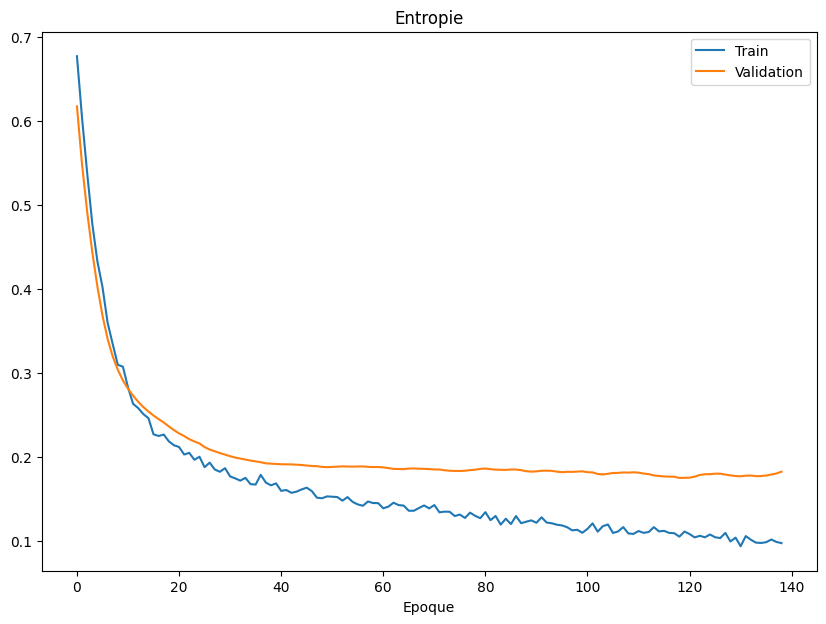

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(hist.history['loss'], label='Train')
ax.plot(hist.history['val_loss'], label='Validation')
ax.set_xlabel('Epoque')
ax.set_title('Entropie')
ax.legend(loc='best')
plt.show()

Ca dérive beaucoup plus tard (grâce au dropout)